In [62]:
# Step 1: Import Required Libraries
import os
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, Dense, Dropout, Flatten, Conv2D, MaxPooling2D, 
                                     Concatenate, LayerNormalization, MultiHeadAttention, GlobalAveragePooling1D)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
import tensorflow as tf


In [63]:
# Step 2: Load and Clean Clinical Data
df = pd.read_csv('BC_cardiotox_clinical_variables.csv')

# Convert comma decimal to dot in string-based numeric columns
cols_to_fix = ['height', 'LVEF', 'PWT', 'LAd', 'LVDd', 'LVSd']
for col in cols_to_fix:
    df[col] = df[col].astype(str).str.replace(',', '.').astype(float)

# Drop rows with any NaNs (or use imputation as an alternative)
df.dropna(inplace=True)

# Reset index
df.reset_index(drop=True, inplace=True)


In [67]:
import os
import cv2
import numpy as np

# Image directory and target size
IMG_DIR = 'images'
IMG_SIZE = 128

# Modified loader: map "0.png" → "image (0).png"
def load_image(file_name):
    base_name = file_name.replace('.png', '')  # extract just the number
    real_name = f"image ({base_name}).png"
    img_path = os.path.join(IMG_DIR, real_name)

    if not os.path.exists(img_path):
        print(f"[WARNING] Missing image: {img_path}")
        return np.zeros((IMG_SIZE, IMG_SIZE, 3))

    img = cv2.imread(img_path, cv2.IMREAD_COLOR)
    if img is None:
        print(f"[ERROR] Couldn't read: {img_path}")
        return np.zeros((IMG_SIZE, IMG_SIZE, 3))

    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = img / 255.0
    return img

# Apply safely
df['image'] = df['image_name'].apply(load_image)


[WARNING] Missing image: images\image (0).png
[WARNING] Missing image: images\image (271).png
[WARNING] Missing image: images\image (272).png
[WARNING] Missing image: images\image (273).png
[WARNING] Missing image: images\image (274).png
[WARNING] Missing image: images\image (275).png
[WARNING] Missing image: images\image (276).png
[WARNING] Missing image: images\image (277).png
[WARNING] Missing image: images\image (280).png
[WARNING] Missing image: images\image (281).png
[WARNING] Missing image: images\image (282).png
[WARNING] Missing image: images\image (283).png
[WARNING] Missing image: images\image (284).png
[WARNING] Missing image: images\image (285).png
[WARNING] Missing image: images\image (286).png
[WARNING] Missing image: images\image (287).png
[WARNING] Missing image: images\image (288).png
[WARNING] Missing image: images\image (289).png
[WARNING] Missing image: images\image (291).png
[WARNING] Missing image: images\image (292).png
[WARNING] Missing image: images\image (294

In [68]:
missing_images = [
    f"image ({img.replace('.png','')}).png"
    for img in df['image_name']
    if not os.path.exists(os.path.join(IMG_DIR, f"image ({img.replace('.png','')}).png"))
]

print(f"Missing {len(missing_images)} image(s): {missing_images[:5]}")


Missing 231 image(s): ['image (0).png', 'image (271).png', 'image (272).png', 'image (273).png', 'image (274).png']


In [69]:
# Step 3: Prepare the features and labels
X_clinical = df.drop(columns=['image_name', 'image', 'CTRCD'])
scaler = StandardScaler()
X_clinical_scaled = scaler.fit_transform(X_clinical)

X_image = np.stack(df['image'].values)
y = df['CTRCD'].values
y_cat = to_categorical(y)

In [70]:
# Step 4: Train-test split
Xc_train, Xc_test, Xi_train, Xi_test, y_train, y_test = train_test_split(
    X_clinical_scaled, X_image, y_cat, test_size=0.2, random_state=42, stratify=y)

In [71]:
# Step 5: Build hybrid CNN + Transformer model
img_input = Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = Conv2D(32, (3,3), activation='relu')(img_input)
x = MaxPooling2D((2,2))(x)
x = Conv2D(64, (3,3), activation='relu')(x)
x = MaxPooling2D((2,2))(x)
x = Flatten()(x)
x = Dense(128, activation='relu')(x)
img_features = Dropout(0.5)(x)

clinical_input = Input(shape=(Xc_train.shape[1],))
clinical_features = Dense(128, activation='relu')(clinical_input)

merged = Concatenate()([img_features, clinical_features])
merged = tf.expand_dims(merged, axis=1)

attn_output = MultiHeadAttention(num_heads=4, key_dim=32)(merged, merged)
attn_output = LayerNormalization()(attn_output)
attn_output = GlobalAveragePooling1D()(attn_output)

dense = Dense(64, activation='relu')(attn_output)
output = Dense(2, activation='softmax')(dense)

model = Model(inputs=[img_input, clinical_input], outputs=output)
model.compile(optimizer=Adam(1e-4), loss='categorical_crossentropy', metrics=['accuracy'])

In [72]:
# Step 6: Train the model
history = model.fit(
    [Xi_train, Xc_train], y_train,
    validation_split=0.1,
    epochs=30,
    batch_size=16
)


Epoch 1/30


21/21 [==============================] - 8s 230ms/step - loss: 0.3745 - accuracy: 0.8922 - val_loss: 0.3674 - val_accuracy: 0.8947
Epoch 2/30
21/21 [==============================] - 4s 194ms/step - loss: 0.2653 - accuracy: 0.9042 - val_loss: 0.4082 - val_accuracy: 0.8947
Epoch 3/30
21/21 [==============================] - 4s 207ms/step - loss: 0.2239 - accuracy: 0.9102 - val_loss: 0.4147 - val_accuracy: 0.8947
Epoch 4/30
21/21 [==============================] - 5s 218ms/step - loss: 0.2031 - accuracy: 0.9251 - val_loss: 0.4418 - val_accuracy: 0.8684
Epoch 5/30
21/21 [==============================] - 4s 195ms/step - loss: 0.1660 - accuracy: 0.9431 - val_loss: 0.4629 - val_accuracy: 0.8947
Epoch 6/30
21/21 [==============================] - 4s 206ms/step - loss: 0.1414 - accuracy: 0.9431 - val_loss: 0.4874 - val_accuracy: 0.8947
Epoch 7/30
21/21 [==============================] - 4s 193ms/step - loss: 0.1281 - accuracy: 0.9521 - val_loss: 0.5103 - val_accuracy: 0.8684
Epoc

In [73]:

# Step 7: Evaluate the model
y_pred_prob = model.predict([Xi_test, Xc_test])
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = np.argmax(y_test, axis=1)

acc = accuracy_score(y_true, y_pred)
cm = confusion_matrix(y_true, y_pred)
report = classification_report(y_true, y_pred, target_names=["NO_CTRCD", "CTRCD"])


3/3 [==============================] - 1s 87ms/step


In [75]:
# Step 8: Save the model
model.save('cardiotoxicity_hybrid_model.h5')

3/3 [==============================] - 0s 89ms/step


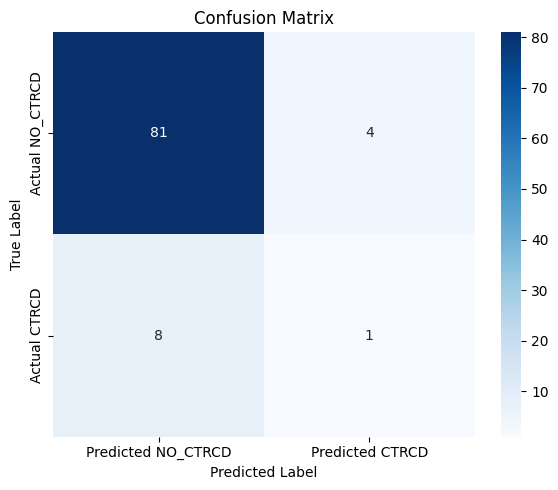

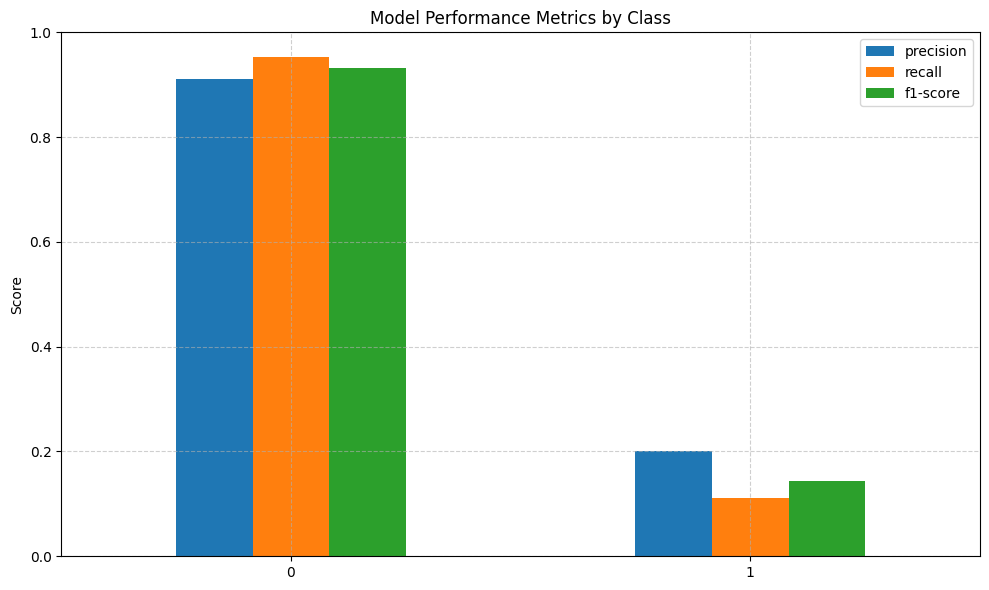

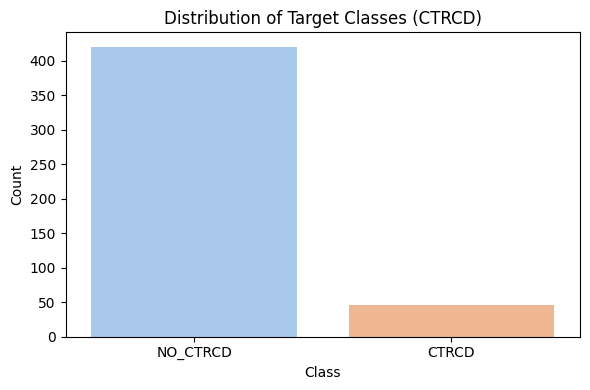

In [77]:
# Recalculating y_true and y_pred from saved model predictions if not defined
from tensorflow.keras.models import load_model

# Reload model if needed
model = load_model('cardiotoxicity_hybrid_model.h5')

# Recalculate predictions
y_pred_prob = model.predict([Xi_test, Xc_test])
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = np.argmax(y_test, axis=1)

# Re-import libraries for visualization
import seaborn as sns
import matplotlib.pyplot as plt

# Confusion matrix and classification report
cm = confusion_matrix(y_true, y_pred)
report_dict = classification_report(y_true, y_pred, output_dict=True)

# Visualization: Confusion Matrix
def plot_confusion_matrix(cm, labels):
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=[f'Predicted {l}' for l in labels],
                yticklabels=[f'Actual {l}' for l in labels])
    plt.title('Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()

# Visualization: Classification Report
def plot_classification_report(report_dict):
    df_report = pd.DataFrame(report_dict).transpose().drop(index=["accuracy", "macro avg", "weighted avg"])
    df_report[['precision', 'recall', 'f1-score']].plot(kind='bar', figsize=(10, 6))
    plt.title("Model Performance Metrics by Class")
    plt.ylabel("Score")
    plt.ylim(0, 1)
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

# Visualization: Target Class Distribution
def plot_class_distribution(y_labels):
    plt.figure(figsize=(6, 4))
    sns.countplot(x=y_labels, palette='pastel')
    plt.title('Distribution of Target Classes (CTRCD)')
    plt.xticks(ticks=[0, 1], labels=['NO_CTRCD', 'CTRCD'])
    plt.xlabel('Class')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()

# Call all visualizations
plot_confusion_matrix(cm, labels=["NO_CTRCD", "CTRCD"])
plot_classification_report(report_dict)
plot_class_distribution(df['CTRCD'].values)


In [83]:
from tensorflow.keras.layers import LSTM, GRU, Reshape

# Define three model-building functions

def build_cnn_lstm_model(input_img_shape, clinical_shape):
    img_input = Input(shape=input_img_shape)
    x = Conv2D(32, (3,3), activation='relu')(img_input)
    x = MaxPooling2D((2,2))(x)
    x = Conv2D(64, (3,3), activation='relu')(x)
    x = MaxPooling2D((2,2))(x)
    x = Flatten()(x)
    x = Dense(128, activation='relu')(x)
    img_features = Dropout(0.5)(x)

    clinical_input = Input(shape=(clinical_shape,))
    clinical_features = Dense(128, activation='relu')(clinical_input)

    merged = Concatenate()([img_features, clinical_features])
    merged = Reshape((1, -1))(merged)
    lstm_out = LSTM(64)(merged)
    dense = Dense(64, activation='relu')(lstm_out)
    output = Dense(2, activation='softmax')(dense)

    model = Model(inputs=[img_input, clinical_input], outputs=output)
    return model


def build_cnn_gru_model(input_img_shape, clinical_shape):
    img_input = Input(shape=input_img_shape)
    x = Conv2D(32, (3,3), activation='relu')(img_input)
    x = MaxPooling2D((2,2))(x)
    x = Conv2D(64, (3,3), activation='relu')(x)
    x = MaxPooling2D((2,2))(x)
    x = Flatten()(x)
    x = Dense(128, activation='relu')(x)
    img_features = Dropout(0.5)(x)

    clinical_input = Input(shape=(clinical_shape,))
    clinical_features = Dense(128, activation='relu')(clinical_input)

    merged = Concatenate()([img_features, clinical_features])
    merged = Reshape((1, -1))(merged)
    gru_out = GRU(64)(merged)
    dense = Dense(64, activation='relu')(gru_out)
    output = Dense(2, activation='softmax')(dense)

    model = Model(inputs=[img_input, clinical_input], outputs=output)
    return model


# Train and evaluate both models
def train_and_evaluate(model_builder, model_name):
    model = model_builder((IMG_SIZE, IMG_SIZE, 3), Xc_train.shape[1])
    model.compile(optimizer=Adam(1e-4), loss='categorical_crossentropy', metrics=['accuracy'])
    model.fit([Xi_train, Xc_train], y_train, validation_split=0.1, epochs=30, batch_size=16, verbose=0)

    y_pred_prob = model.predict([Xi_test, Xc_test])
    y_pred = np.argmax(y_pred_prob, axis=1)
    y_true = np.argmax(y_test, axis=1)

    cm = confusion_matrix(y_true, y_pred)
    acc = accuracy_score(y_true, y_pred)
    report = classification_report(y_true, y_pred, target_names=["NO_CTRCD", "CTRCD"])
    
    model.save(f'{model_name}.h5')

    return model_name, acc, cm, report

# Train both models
results = []
results.append(train_and_evaluate(build_cnn_lstm_model, "cnn_lstm_model"))
results.append(train_and_evaluate(build_cnn_gru_model, "cnn_gru_model"))

# Prepare results for display
conf_matrices = []
for name, acc, cm, report in results:
    print(f"\n{name} - Accuracy: {acc:.2%}")
    print("Confusion Matrix:")
    print(cm)
    print("Classification Report:")
    print(report)
    conf_matrices.append(pd.DataFrame(cm, index=["NO_CTRCD", "CTRCD"], columns=["Pred_NO_CTRCD", "Pred_CTRCD"]))



3/3 [==============================] - 1s 73ms/step

cnn_lstm_model - Accuracy: 90.43%
Confusion Matrix:
[[85  0]
 [ 9  0]]
Classification Report:
              precision    recall  f1-score   support

    NO_CTRCD       0.90      1.00      0.95        85
       CTRCD       0.00      0.00      0.00         9

    accuracy                           0.90        94
   macro avg       0.45      0.50      0.47        94
weighted avg       0.82      0.90      0.86        94


cnn_gru_model - Accuracy: 89.36%
Confusion Matrix:
[[84  1]
 [ 9  0]]
Classification Report:
              precision    recall  f1-score   support

    NO_CTRCD       0.90      0.99      0.94        85
       CTRCD       0.00      0.00      0.00         9

    accuracy                           0.89        94
   macro avg       0.45      0.49      0.47        94
weighted avg       0.82      0.89      0.85        94



In [85]:
# Re-import everything due to code execution reset
import os
import cv2
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, Dense, Dropout, Flatten, Conv2D, MaxPooling2D, 
                                     Concatenate, LayerNormalization, MultiHeadAttention, GlobalAveragePooling1D)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from imblearn.over_sampling import SMOTE
import tensorflow as tf

# Re-load the dataset
csv_path = "BC_cardiotox_clinical_variables.csv"
df = pd.read_csv(csv_path)

# Fix comma decimal issue
columns_to_fix = ['height', 'LVEF', 'PWT', 'LAd', 'LVDd', 'LVSd']
for col in columns_to_fix:
    df[col] = df[col].astype(str).str.replace(',', '.').astype(float)

# Drop rows with missing values
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)

# Load and process image data
IMG_DIR = 'images'
IMG_SIZE = 128

def load_image(file_name):
    base_name = file_name.replace('.png', '')  # "0"
    real_name = f"image ({base_name}).png"
    img_path = os.path.join(IMG_DIR, real_name)

    if not os.path.exists(img_path):
        return np.zeros((IMG_SIZE, IMG_SIZE, 3))

    img = cv2.imread(img_path, cv2.IMREAD_COLOR)
    if img is None:
        return np.zeros((IMG_SIZE, IMG_SIZE, 3))

    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = img / 255.0
    return img

df['image'] = df['image_name'].apply(load_image)

# Extract features and labels
X_clinical = df.drop(columns=['image_name', 'image', 'CTRCD'])
scaler = StandardScaler()
X_clinical_scaled = scaler.fit_transform(X_clinical)
X_image = np.stack(df['image'].values)
y = df['CTRCD'].values

# Flatten image features for SMOTE
X_image_flat = X_image.reshape((X_image.shape[0], -1))

# Combine both clinical and image features
X_combined = np.concatenate([X_clinical_scaled, X_image_flat], axis=1)

# Apply SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_combined, y)

# Split back into clinical and image features
X_clinical_res = X_resampled[:, :X_clinical_scaled.shape[1]]
X_image_res = X_resampled[:, X_clinical_scaled.shape[1]:].reshape(-1, IMG_SIZE, IMG_SIZE, 3)
y_cat_res = to_categorical(y_resampled)

# Train-test split
Xc_train, Xc_test, Xi_train, Xi_test, y_train, y_test = train_test_split(
    X_clinical_res, X_image_res, y_cat_res, test_size=0.2, random_state=42, stratify=y_resampled)

# Build the CNN + Transformer model
img_input = Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = Conv2D(32, (3,3), activation='relu')(img_input)
x = MaxPooling2D((2,2))(x)
x = Conv2D(64, (3,3), activation='relu')(x)
x = MaxPooling2D((2,2))(x)
x = Flatten()(x)
x = Dense(128, activation='relu')(x)
img_features = Dropout(0.5)(x)

clinical_input = Input(shape=(Xc_train.shape[1],))
clinical_features = Dense(128, activation='relu')(clinical_input)

merged = Concatenate()([img_features, clinical_features])
merged = tf.expand_dims(merged, axis=1)

attn_output = MultiHeadAttention(num_heads=4, key_dim=32)(merged, merged)
attn_output = LayerNormalization()(attn_output)
attn_output = GlobalAveragePooling1D()(attn_output)

dense = Dense(64, activation='relu')(attn_output)
output = Dense(2, activation='softmax')(dense)

model = Model(inputs=[img_input, clinical_input], outputs=output)
model.compile(optimizer=Adam(1e-4), loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(
    [Xi_train, Xc_train], y_train,
    validation_split=0.1,
    epochs=30,
    batch_size=16,
    verbose=1
)

# Evaluate the model
y_pred_prob = model.predict([Xi_test, Xc_test])
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = np.argmax(y_test, axis=1)

# Metrics
acc = accuracy_score(y_true, y_pred)
cm = confusion_matrix(y_true, y_pred)
report = classification_report(y_true, y_pred, target_names=["NO_CTRCD", "CTRCD"])

# Save model
model.save('cardiotoxicity_cnn_transformer_smote_model.h5')




Epoch 1/30
38/38 [==============================] - 11s 216ms/step - loss: 0.6063 - accuracy: 0.6937 - val_loss: 0.5462 - val_accuracy: 0.7059
Epoch 2/30
38/38 [==============================] - 8s 200ms/step - loss: 0.3905 - accuracy: 0.8278 - val_loss: 0.4273 - val_accuracy: 0.8235
Epoch 3/30
38/38 [==============================] - 8s 201ms/step - loss: 0.2673 - accuracy: 0.9040 - val_loss: 0.3875 - val_accuracy: 0.8382
Epoch 4/30
38/38 [==============================] - 7s 196ms/step - loss: 0.1892 - accuracy: 0.9338 - val_loss: 0.2635 - val_accuracy: 0.8824
Epoch 5/30
38/38 [==============================] - 7s 194ms/step - loss: 0.1480 - accuracy: 0.9503 - val_loss: 0.1866 - val_accuracy: 0.9412
Epoch 6/30
38/38 [==============================] - 8s 202ms/step - loss: 0.0979 - accuracy: 0.9702 - val_loss: 0.1787 - val_accuracy: 0.9412
Epoch 7/30
38/38 [==============================] - 7s 194ms/step - loss: 0.0676 - accuracy: 0.9834 - val_loss: 0.1589 - val_accuracy: 0.9706
Epoch

6/6 [==============================] - 1s 63ms/step


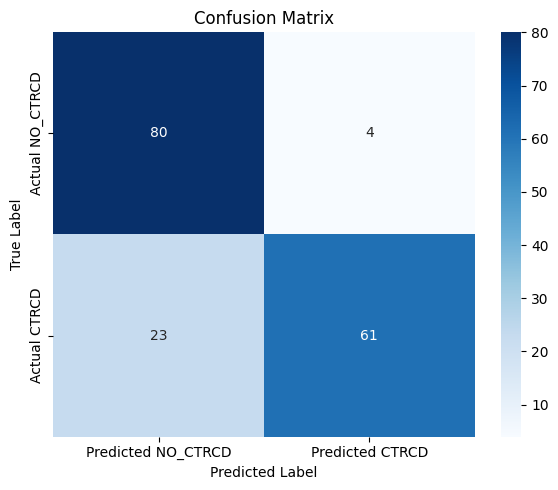

In [94]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from tensorflow.keras.models import load_model

# Load the saved model
model = load_model('cardiotoxicity_hybrid_model.h5')

# Predict
y_pred_prob = model.predict([Xi_test, Xc_test])
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = np.argmax(y_test, axis=1)

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Predicted NO_CTRCD", "Predicted CTRCD"],
            yticklabels=["Actual NO_CTRCD", "Actual CTRCD"])
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()


In [96]:
# Re-implement SMOTE preprocessing and apply to CNN+LSTM and CNN+GRU models

import os
import cv2
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, Dense, Dropout, Flatten, Conv2D, MaxPooling2D, 
                                     Concatenate, Reshape, LSTM, GRU)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from imblearn.over_sampling import SMOTE
import tensorflow as tf

# Load dataset
csv_path = "BC_cardiotox_clinical_variables.csv"
df = pd.read_csv(csv_path)

# Fix decimal commas
columns_to_fix = ['height', 'LVEF', 'PWT', 'LAd', 'LVDd', 'LVSd']
for col in columns_to_fix:
    df[col] = df[col].astype(str).str.replace(',', '.').astype(float)
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)

# Load images
IMG_DIR = 'images'
IMG_SIZE = 128

def load_image(file_name):
    base_name = file_name.replace('.png', '')
    real_name = f"image ({base_name}).png"
    img_path = os.path.join(IMG_DIR, real_name)
    if not os.path.exists(img_path): return np.zeros((IMG_SIZE, IMG_SIZE, 3))
    img = cv2.imread(img_path, cv2.IMREAD_COLOR)
    if img is None: return np.zeros((IMG_SIZE, IMG_SIZE, 3))
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    return img / 255.0

df['image'] = df['image_name'].apply(load_image)

# Extract features
X_clinical = df.drop(columns=['image_name', 'image', 'CTRCD'])
scaler = StandardScaler()
X_clinical_scaled = scaler.fit_transform(X_clinical)
X_image = np.stack(df['image'].values)
y = df['CTRCD'].values

# Flatten image for SMOTE
X_image_flat = X_image.reshape((X_image.shape[0], -1))
X_combined = np.concatenate([X_clinical_scaled, X_image_flat], axis=1)

# Apply SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_combined, y)

# Split back into clinical and image features
X_clinical_res = X_resampled[:, :X_clinical_scaled.shape[1]]
X_image_res = X_resampled[:, X_clinical_scaled.shape[1]:].reshape(-1, IMG_SIZE, IMG_SIZE, 3)
y_cat_res = to_categorical(y_resampled)

# Train-test split
Xc_train, Xc_test, Xi_train, Xi_test, y_train, y_test = train_test_split(
    X_clinical_res, X_image_res, y_cat_res, test_size=0.2, random_state=42, stratify=y_resampled)

# Define models
def build_cnn_lstm_model(input_img_shape, clinical_shape):
    img_input = Input(shape=input_img_shape)
    x = Conv2D(32, (3,3), activation='relu')(img_input)
    x = MaxPooling2D((2,2))(x)
    x = Conv2D(64, (3,3), activation='relu')(x)
    x = MaxPooling2D((2,2))(x)
    x = Flatten()(x)
    x = Dense(128, activation='relu')(x)
    img_features = Dropout(0.5)(x)

    clinical_input = Input(shape=(clinical_shape,))
    clinical_features = Dense(128, activation='relu')(clinical_input)

    merged = Concatenate()([img_features, clinical_features])
    merged = Reshape((1, -1))(merged)
    lstm_out = LSTM(64)(merged)
    dense = Dense(64, activation='relu')(lstm_out)
    output = Dense(2, activation='softmax')(dense)

    model = Model(inputs=[img_input, clinical_input], outputs=output)
    return model

def build_cnn_gru_model(input_img_shape, clinical_shape):
    img_input = Input(shape=input_img_shape)
    x = Conv2D(32, (3,3), activation='relu')(img_input)
    x = MaxPooling2D((2,2))(x)
    x = Conv2D(64, (3,3), activation='relu')(x)
    x = MaxPooling2D((2,2))(x)
    x = Flatten()(x)
    x = Dense(128, activation='relu')(x)
    img_features = Dropout(0.5)(x)

    clinical_input = Input(shape=(clinical_shape,))
    clinical_features = Dense(128, activation='relu')(clinical_input)

    merged = Concatenate()([img_features, clinical_features])
    merged = Reshape((1, -1))(merged)
    gru_out = GRU(64)(merged)
    dense = Dense(64, activation='relu')(gru_out)
    output = Dense(2, activation='softmax')(dense)

    model = Model(inputs=[img_input, clinical_input], outputs=output)
    return model

# Train and evaluate function
def train_and_evaluate(model_builder, model_name):
    model = model_builder((IMG_SIZE, IMG_SIZE, 3), Xc_train.shape[1])
    model.compile(optimizer=Adam(1e-4), loss='categorical_crossentropy', metrics=['accuracy'])
    model.fit([Xi_train, Xc_train], y_train, validation_split=0.1, epochs=30, batch_size=16, verbose=0)

    y_pred_prob = model.predict([Xi_test, Xc_test])
    y_pred = np.argmax(y_pred_prob, axis=1)
    y_true = np.argmax(y_test, axis=1)

    cm = confusion_matrix(y_true, y_pred)
    acc = accuracy_score(y_true, y_pred)
    report = classification_report(y_true, y_pred, target_names=["NO_CTRCD", "CTRCD"])

    model.save(f'{model_name}.h5')

    return model_name, acc, cm, report

# Run for both models
results = []
results.append(train_and_evaluate(build_cnn_lstm_model, "cnn_lstm_model_smote"))
results.append(train_and_evaluate(build_cnn_gru_model, "cnn_gru_model_smote"))

# Display summary
model_summary_df = pd.DataFrame(
    [(name, acc) for name, acc, _, _ in results],
    columns=["Model", "Accuracy"]
)




6/6 [==============================] - 1s 56ms/step
